Fake Profile Detection using ANN


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')       

In [2]:
df = pd.read_csv('user_fake_authentic_2class.csv')

In [20]:
df.head()

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,fo,cs,pi,class
0,44,48,325,33,1,0,12,0.0,0.0,0.00,0.00,0.000,0.0,0.0,0.000,0.111111,0.094985,f
1,10,66,321,150,1,0,213,0.0,1.0,14.39,1.97,0.000,1.5,0.0,0.000,0.206826,230.412857,f
2,33,970,308,101,1,1,436,0.0,1.0,10.10,0.30,0.000,2.5,0.0,0.056,0.572174,43.569939,f
3,70,86,360,14,1,0,0,1.0,0.0,0.78,0.06,0.000,0.0,0.0,0.000,1.000000,5.859799,f
4,3,21,285,73,1,0,93,0.0,0.0,14.29,0.00,0.667,0.0,0.0,0.000,0.300494,0.126019,f


In [6]:
df.isnull().sum()

pos      0
flw      0
flg      0
bl       0
pic      0
lin      0
cl       0
cz       0
ni       0
erl      0
erc      0
lt       0
hc       0
pr       0
fo       0
cs       0
pi       0
class    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1082)

In [9]:
df.shape

(65326, 18)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(64244, 18)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 64244 entries, 0 to 65325
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     64244 non-null  int64  
 1   flw     64244 non-null  int64  
 2   flg     64244 non-null  int64  
 3   bl      64244 non-null  int64  
 4   pic     64244 non-null  int64  
 5   lin     64244 non-null  int64  
 6   cl      64244 non-null  int64  
 7   cz      64244 non-null  float64
 8   ni      64244 non-null  float64
 9   erl     64244 non-null  float64
 10  erc     64244 non-null  float64
 11  lt      64244 non-null  float64
 12  hc      64244 non-null  float64
 13  pr      64244 non-null  float64
 14  fo      64244 non-null  float64
 15  cs      64244 non-null  float64
 16  pi      64244 non-null  float64
 17  class   64244 non-null  str    
dtypes: float64(10), int64(7), str(1)
memory usage: 9.4 MB


In [14]:
X = df.drop("class", axis=1)
y = df["class"]

Label encode of Target fiture

In [24]:
y = df["class"].map({"f": 0, "r": 1})

In [25]:
y.isnull().sum()

np.int64(0)

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state= 42,
    test_size= 0.2,
    stratify= y
)

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [52]:
model = Sequential([
    Dense(17, input_dim = 17, activation= 'relu'),
    Dense(32, activation= 'relu'),
    Dense(16, activation= 'relu'),
    Dense(1, activation='sigmoid')
])

In [55]:
model.compile(optimizer='adam', loss= 'binary_crossentropy', metrics=['accuracy'])

In [56]:
X_train_scaled.shape

(51395, 17)

In [57]:
model.input_shape

(None, 17)

In [58]:
history = model.fit(X_train_scaled, y_train,
                    epochs =100, batch_size = 8,
                    validation_split = 0.2,
                    verbose = 1)

Epoch 1/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8304 - loss: 0.3909 - val_accuracy: 0.8504 - val_loss: 0.3492
Epoch 2/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8581 - loss: 0.3271 - val_accuracy: 0.8585 - val_loss: 0.3221
Epoch 3/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8649 - loss: 0.3095 - val_accuracy: 0.8601 - val_loss: 0.3141
Epoch 4/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8680 - loss: 0.3019 - val_accuracy: 0.8614 - val_loss: 0.3079
Epoch 5/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8703 - loss: 0.2968 - val_accuracy: 0.8621 - val_loss: 0.3083
Epoch 6/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8723 - loss: 0.2935 - val_accuracy: 0.8637 - val_loss: 0.3011
Epoch 7/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8741 - loss: 0.2887 - val_accuracy: 0.8647 - val_loss: 0.2980
Epoch 8/100
5140/5140 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8746 - loss: 0

In [59]:
loss, acc = model.evaluate(X_test_scaled, y_test, verbose= 1)

402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8864 - loss: 0.2613


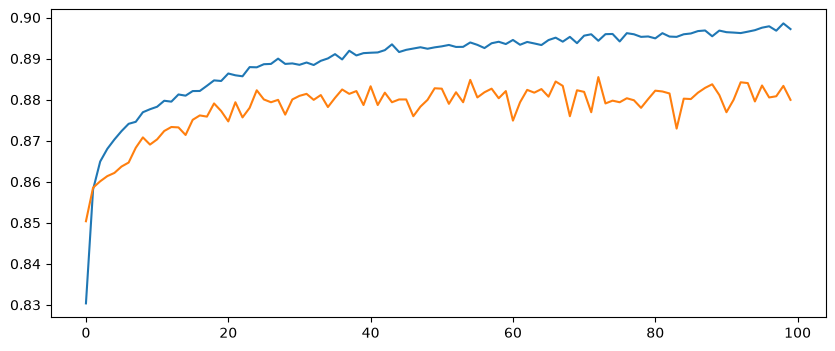

In [60]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')

In [61]:
y_pred_prob = model.predict(X_test_scaled)

402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step


In [62]:
y_pred = (y_pred_prob > 0.5).astype(int)

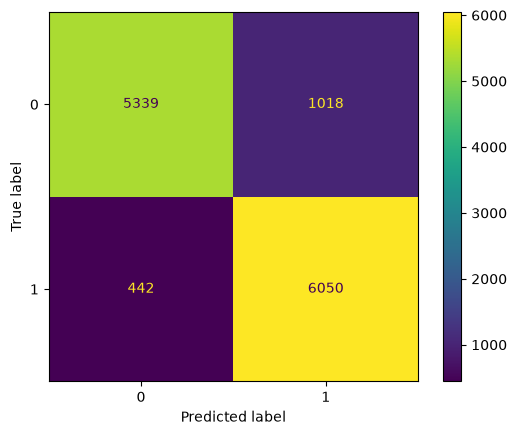

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      6357
           1       0.86      0.93      0.89      6492

    accuracy                           0.89     12849
   macro avg       0.89      0.89      0.89     12849
weighted avg       0.89      0.89      0.89     12849



In [65]:
import joblib

joblib.dump(scaler, "scaler.pkl")
model.save("fake_profile_ann.keras")